# 1. Setup

Importa somente as ferramentas necessárias para uso mais econômico da memória.

In [1]:
import numpy as np
from numpy import dtype, ndarray, str_, int_, floating
from pandas import read_csv, DataFrame, Series
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 2. Carregando o Dataset e inspeções iniciais

In [2]:
# Análise dos dados de entrada

# Caminho para a fonte de dados
# source_path: str = 'Iris.csv' # Local
source_path: str = '/kaggle/input/datasets/menegidio/iris-species/Iris.csv' # Kaggle
target_column: str = 'Species' # Coluna da variável-alvo

# Lê o arquivo, define a primeira linha como cabeçalho e a primeira coluna "Id" como identificador
data: DataFrame = read_csv(source_path,
    header=0,
    index_col=0,
    dtype={
        'SepalLengthCm': np.float32,
        'SepalWidthCm': np.float32,
        'PetalLengthCm': np.float32,
        'PetalWidthCm': np.float32,
        'Species': str
    }
)

# Imprime a fonte de dados carregada sem alterações (apenas as primeiras 5 amostras)
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


---

É possível observar que o uso de memória é drasticamente reduzido ao definir as medidas para tipo decimal `float32` ao invés do padrão `float64`

In [3]:
# Imprime os tipos de dados presentes no DataFrame para desenvolvimento
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float32
 1   SepalWidthCm   150 non-null    float32
 2   PetalLengthCm  150 non-null    float32
 3   PetalWidthCm   150 non-null    float32
 4   Species        150 non-null    object 
dtypes: float32(4), object(1)
memory usage: 4.7+ KB


# 3. Preparando a estrutura dos dados

In [4]:
# Define os dados de entrada "x" sem a coluna de variável-alvo, que é armazenada em "y"
x: DataFrame = data.drop(columns=[target_column])
y: 'Series[str_]' = data[target_column]

# Armazena as possíveis classificações de espécies e mapeia seus índices em um dicionário
species_names: ndarray[tuple[int], dtype[str_]] = y.unique()
species_ids: dict[str_, int] = {name: i for i, name in enumerate(species_names)}

# Mapeia a coluna "Species" para uma nova coluna de identificação numeral
data['SpeciesId'] = data['Species'].map(species_ids)

# Imprime as primeiras 100 amostras do DataFrame estruturado
data.head(100)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,SpeciesId
Id,,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa,0
2,4.9,3.0,1.4,0.2,Iris-setosa,0
3,4.7,3.2,1.3,0.2,Iris-setosa,0
4,4.6,3.1,1.5,0.2,Iris-setosa,0
5,5.0,3.6,1.4,0.2,Iris-setosa,0
...,...,...,...,...,...,...
96,5.7,3.0,4.2,1.2,Iris-versicolor,1
97,5.7,2.9,4.2,1.3,Iris-versicolor,1
98,6.2,2.9,4.3,1.3,Iris-versicolor,1


# 4. Inspeções finais dos dados

Visualização gráfica e informações relevantes da estrutura de dados.

In [5]:
# Imprime a estrutura dos dados para análise
print("Dimensão do dataset:", data.shape)

print("\nNomes das colunas:")
for column in data.columns:
    print('-', column)
    
# Utiliza o método "value_counts" para enumerar quantas vezes cada valor está presente na coluna
print("\nContagem por espécie:")
print(data[target_column].value_counts())

# Imprime informações relevantes sobre os dados do Dataset
data.describe()

Dimensão do dataset: (150, 6)

Nomes das colunas:
- SepalLengthCm
- SepalWidthCm
- PetalLengthCm
- PetalWidthCm
- Species
- SpeciesId

Contagem por espécie:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,SpeciesId
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,1.000000
std,0.828066,0.433594,1.764420,0.763161,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


---

Visualização gráfica da fonte de dados por variável.

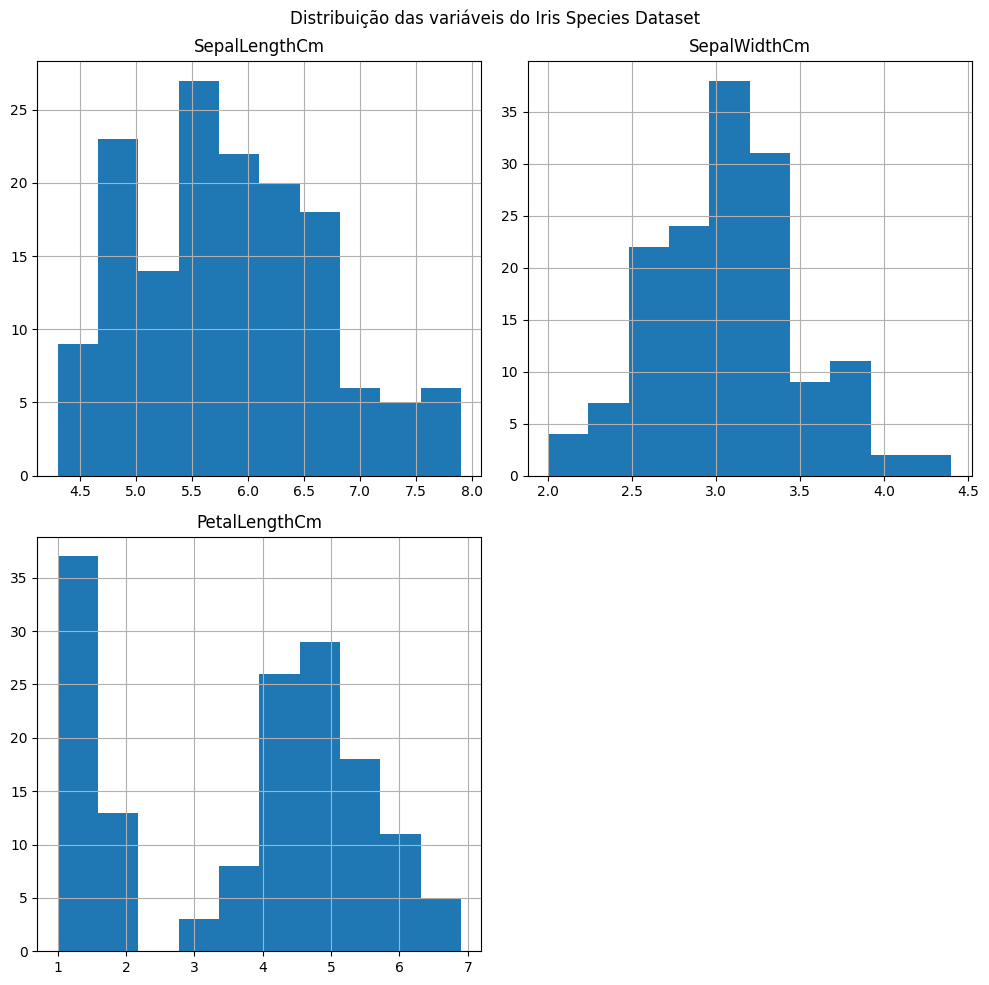

In [6]:
# Exploração visual dos dados

# Visualizações gráficas da distribuição de valores de cada variável
x[x.columns[0:-1]].hist(figsize=(10, 10))
plt.suptitle("Distribuição das variáveis do Iris Species Dataset")
plt.tight_layout()
plt.show()

---

Utiliza o `scatter` para melhor visualização de dados semelhantes em dois eixos comparativos.

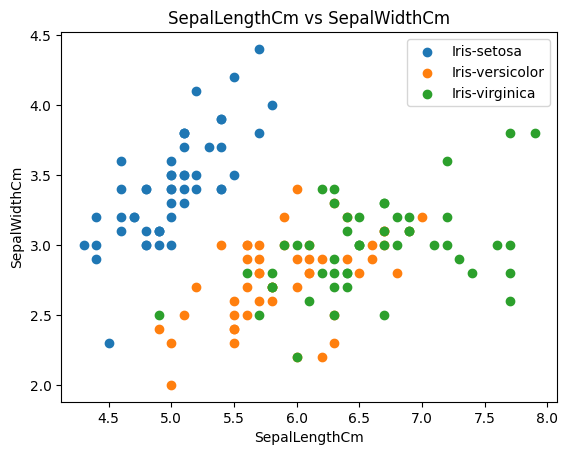

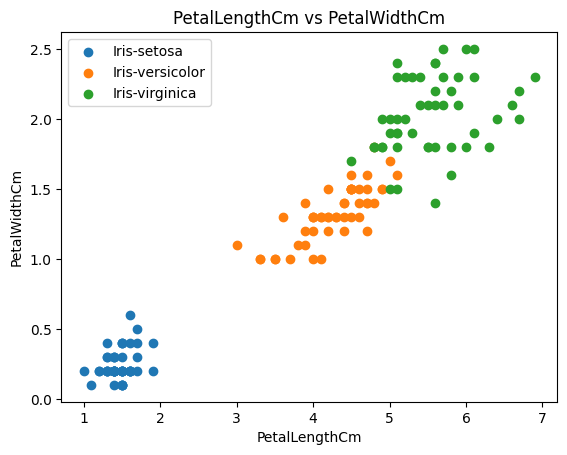

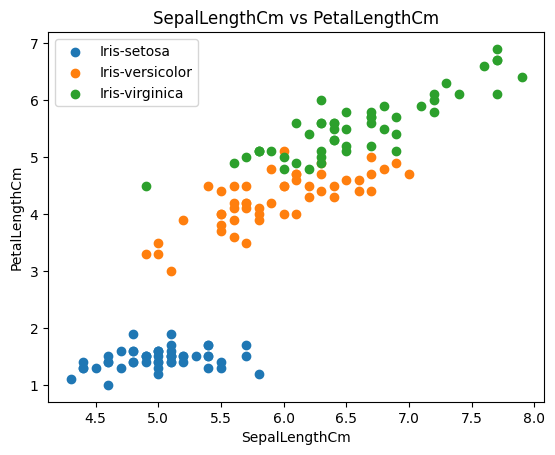

In [7]:
# Visualizações comparativas entre dados relevantes
pairs: list[tuple[str, str]] = [
    ('SepalLengthCm', 'SepalWidthCm'),
    ('PetalLengthCm', 'PetalWidthCm'),
    ('SepalLengthCm', 'PetalLengthCm')
]

# Ilustração scatter para cada comparação
for x_col, y_col in pairs:
    plt.figure()
    for species in species_names:
        subset: DataFrame = data[data[target_column] == species]
        plt.scatter(subset[x_col], subset[y_col], label=species)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col}")
    plt.legend()
    plt.show()

# 5. Divisão de amostras de treino e teste

Aleatoriamente separa os dados de treinamento dos dados de teste de previsão com proporções de 80% e 20%, respectivamente.

In [8]:
# Definindo entradas e saída

# Dividindo as amostras entre treino e teste
x_train: DataFrame
x_test: DataFrame
y_train: 'Series[str_]'
y_test: 'Series[str_]'

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

---

Imprime informações relevantes das amostras para inspeção após divididas entre *train* e *test*.

In [9]:
# Imprime a divisão das amostras para análise
print('Formato de x:', x.shape)
print('Formato de y:', y.shape)

print("\nx_train:", x_train.shape)
print("x_test :", x_test.shape)

print("\nDistribuição em y_train:")
print(y_train.value_counts())
print("\nDistribuição em y_test:")
print(y_test.value_counts())

Formato de x: (150, 4)
Formato de y: (150,)

x_train: (120, 4)
x_test : (30, 4)

Distribuição em y_train:
Species
Iris-setosa        40
Iris-virginica     40
Iris-versicolor    40
Name: count, dtype: int64

Distribuição em y_test:
Species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


# 6. Pré-processamento dos dados

Padroniza em uma *Pipeline* a normalização de escala dos dados e o tipo de vetor calculado, para este caso, um SVC com vetor linear, `C` igual a 1 e `gamma` escalar.

In [10]:
# Padronização dos dados via Objeto Pipeline
pipeline_svm_linear: Pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', C=1, gamma='scale', random_state=42))
])

---

Finalmente, o modelo é treinado na *Pipeline*.

In [11]:
# Treina o modelo com as amostras separadas dentro do Pipeline
pipeline_svm_linear.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=1, kernel='linear', random_state=42))])

# 7. Previsão da variável-alvo

Após o treino do modelo, é utilizado o mesmo *Pipeline* para a classificação das amostras de teste.

In [12]:
# Utiliza o modelo treinado para previsão de classificação das amostras de teste
y_pred_linear: ndarray[tuple[int], dtype[str_]] = pipeline_svm_linear.predict(x_test)

---

Inspeção dos resultados comparativos entre as previsões do modelo e seus rótulos.

In [13]:
# Relatório dos resultados previstos
acc_linear: float = accuracy_score(y_test, y_pred_linear)
print(f"Acurácia do SVM linear: {acc_linear:.4f}")

print("\nRelatório de classificação — SVM linear")
print(classification_report(y_test, y_pred_linear))

Acurácia do SVM linear: 1.0000

Relatório de classificação — SVM linear
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



---

Inspeção gráfica dos rótulos de teste (Y) com as previsões do modelo (X) em forma de matriz de confusão.

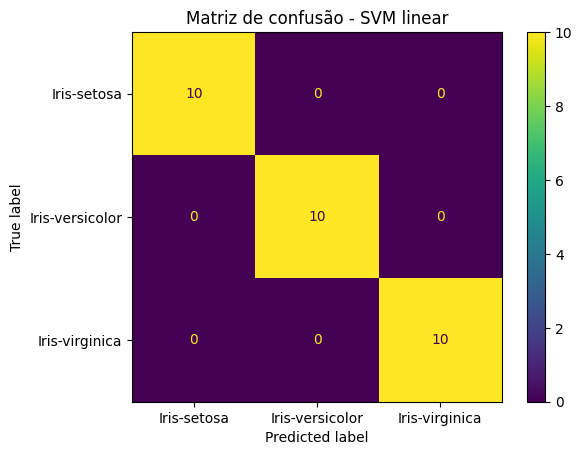

In [14]:
# Representações visuais da matriz de confusão entre classificações do modelo para análise
cm_linear: ndarray[tuple[int], dtype[int_]] = confusion_matrix(y_test, y_pred_linear, labels=species_names)
disp: ConfusionMatrixDisplay = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=species_names)
disp.plot()
plt.title('Matriz de confusão - SVM linear')
plt.show()

# 8. Validação cruzada

Ainda utilizando a mesma *Pipeline*, pode ser feita a verificação do desempenho do modelo em diferentes amostras para avaliar a precisão do modelo em diferentes cenários.

In [15]:
# Validação cruzada do SVM linear para análise do modelo em diferentes amostras
scores_linear: ndarray[tuple[int], dtype[floating]] = cross_val_score(pipeline_svm_linear, x, y, cv=5)

print("Acurácia em cada fold:", scores_linear)
print(f"Média: {scores_linear.mean():.4f}")
print(f"Desvio-padrão: {scores_linear.std():.4f}")

Acurácia em cada fold: [0.96666667 1.         0.93333333 0.93333333 1.        ]
Média: 0.9667
Desvio-padrão: 0.0298
